In [ ]:
# CELL 1 — Install & imports
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

print("All imports done ✓")

All imports done ✓


In [ ]:
# CELL 2 (REPLACEMENT) — Load SECOM via direct download (bypasses ucimlrepo API issues)
import pandas as pd
import numpy as np
import io, requests

# Download features and labels directly from UCI
features_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
labels_url   = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

print("Downloading SECOM features...")
feat_resp = requests.get(features_url, timeout=60)
print("Downloading labels...")
lab_resp  = requests.get(labels_url, timeout=60)

# Parse — features are space-separated, NaN represented as "NaN"
X = pd.read_csv(io.StringIO(feat_resp.text), sep='\s+', header=None)
labels_df = pd.read_csv(io.StringIO(lab_resp.text), sep='\s+', header=None)

# Label column 0 = outcome (-1 fail, 1 pass), column 1 = timestamp (drop it)
y_raw    = labels_df[0]
y_binary = (y_raw == 1).astype(int)   # 1=pass, 0=fail

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape:   {y_raw.shape}")
print(f"\nClass distribution:\n{y_raw.value_counts()}")
print(f"\nMissing values: {X.isnull().sum().sum():,} total")
print(f"Missing %:       {X.isnull().mean().mean()*100:.1f}%")

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15918/3628207210.py:16: SyntaxWarning: invalid escape sequence '\s'
  X = pd.read_csv(io.StringIO(feat_resp.text), sep='\s+', header=None)
/tmp/ipykernel_15918/3628207210.py:17: SyntaxWarning: invalid escape sequence '\s'
  labels_df = pd.read_csv(io.StringIO(lab_resp.text), sep='\s+', header=None)



Features shape: (1567, 590)
Labels shape:   (1567,)

Class distribution:
0
-1    1463
 1     104
Name: count, dtype: int64

Missing values: 41,951 total
Missing %:       4.5%


In [ ]:
# CELL 3 (FIXED) — Missing value handling
threshold = 0.4
X_clean = X.loc[:, X.isnull().mean() < threshold]
print(f"Columns before: {X.shape[1]}, after dropping high-NaN cols: {X_clean.shape[1]}")

X_clean = X_clean.fillna(X_clean.median())

variance = X_clean.var()
X_clean = X_clean.loc[:, variance > 0]
print(f"After removing zero-variance columns: {X_clean.shape[1]} features remain")

y_clean = y_raw.copy()
# y_binary already defined in Cell 2 — do NOT redefine here

print(f"\nFinal: {X_clean.shape[0]} wafers × {X_clean.shape[1]} parameters")
print(f"Pass rate: {y_binary.mean()*100:.1f}%")

Columns before: 590, after dropping high-NaN cols: 558
After removing zero-variance columns: 442 features remain

Final: 1567 wafers × 442 parameters
Pass rate: 6.6%


In [ ]:
# CELL 4 — Correlation analysis: find features most correlated with yield
from scipy import stats

correlations = []
for col in X_clean.columns:
    corr, pval = stats.pointbiserialr(y_binary, X_clean[col])
    correlations.append({'feature': col, 'correlation': corr, 'pvalue': pval})

corr_df = pd.DataFrame(correlations).dropna()
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

print("Top 15 features correlated with yield outcome:")
print(corr_df.head(15)[['feature', 'correlation', 'pvalue']].to_string(index=False))

Top 15 features correlated with yield outcome:
 feature  correlation       pvalue
      59     0.156008 5.341076e-10
     103     0.151230 1.784028e-09
     510     0.131662 1.690389e-07
     348     0.130807 2.033597e-07
     431     0.119936 1.925073e-06
     434     0.111312 1.003005e-05
     430     0.109115 1.499040e-05
      21     0.108333 1.726202e-05
     435     0.108260 1.749182e-05
      28    -0.106987 2.196299e-05
     436     0.106119 2.561714e-05
     210     0.103348 4.153458e-05
     129     0.102799 4.564435e-05
     298     0.101672 5.531227e-05
     163     0.099506 7.959213e-05


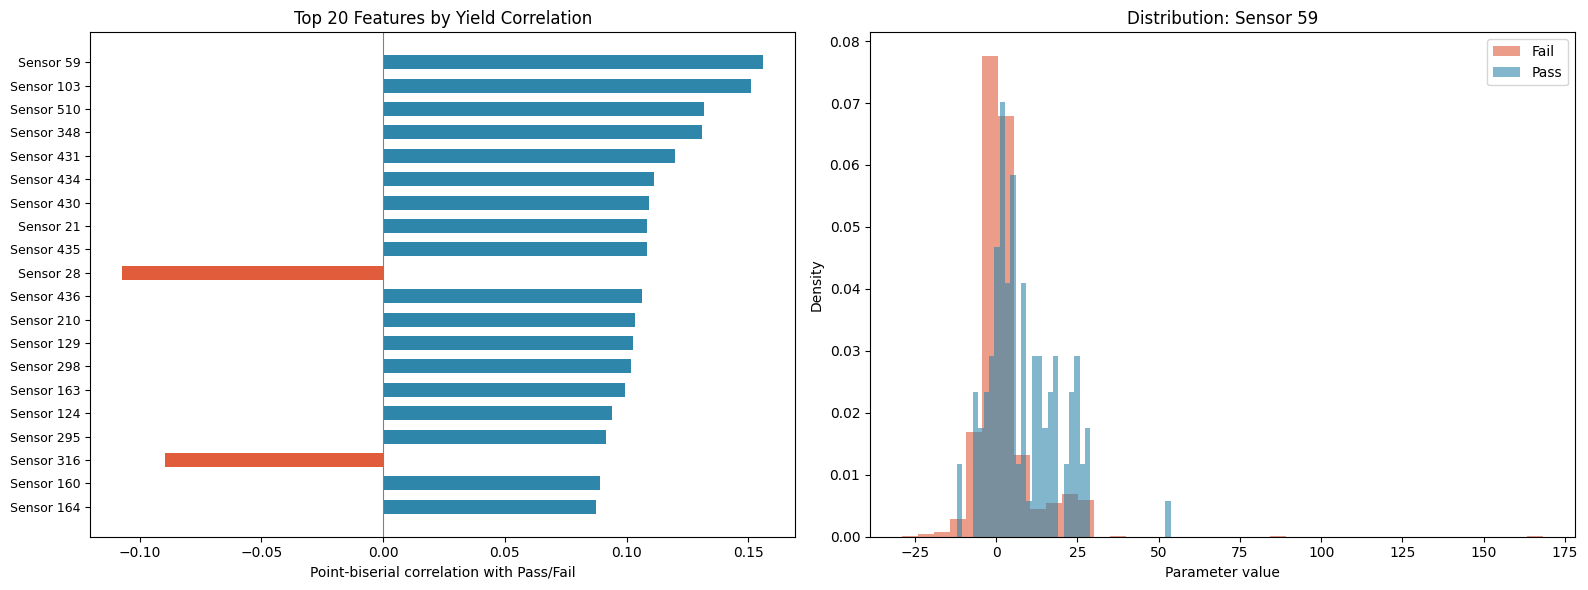

Saved: correlation_analysis.png


In [22]:
# CELL 5 (FIXED) — Visualize top correlated features
top_features = corr_df.head(20).copy()
top_features['label'] = top_features['feature'].apply(lambda x: f'Sensor {x}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart with proper sensor labels
colors = ['#e05c3a' if c < 0 else '#2e86ab' for c in top_features['correlation']]
y_pos = np.arange(len(top_features))
axes[0].barh(y_pos, top_features['correlation'].values, color=colors, height=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_features['label'].values, fontsize=9)
axes[0].set_xlabel('Point-biserial correlation with Pass/Fail')
axes[0].set_title('Top 20 Features by Yield Correlation')
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].invert_yaxis()

# Distribution of pass vs fail for top feature
top_feat = top_features.iloc[0]['feature']
pass_vals = X_clean[top_feat][y_binary == 1]
fail_vals = X_clean[top_feat][y_binary == 0]
axes[1].hist(fail_vals, bins=40, alpha=0.6, color='#e05c3a', label='Fail', density=True)
axes[1].hist(pass_vals, bins=40, alpha=0.6, color='#2e86ab', label='Pass', density=True)
axes[1].set_title(f'Distribution: Sensor {top_feat}')
axes[1].set_xlabel('Parameter value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150)
plt.show()
print("Saved: correlation_analysis.png")

In [ ]:
# CELL 6 — Generate synthetic wafer maps with 3 defect patterns
np.random.seed(42)

WAFER_RADIUS = 8   # grid units

def make_wafer_coords(radius=WAFER_RADIUS):
    coords = [(x, y) for x in range(-radius, radius+1)
                      for y in range(-radius, radius+1)
                      if x**2 + y**2 <= radius**2]
    return np.array(coords)

coords = make_wafer_coords()

def gen_edge_defect(coords, defect_rate=0.25):
    """High defect near edge"""
    r = np.sqrt(coords[:,0]**2 + coords[:,1]**2)
    prob = np.where(r > WAFER_RADIUS * 0.72, defect_rate * 3.5, defect_rate * 0.1)
    return (np.random.rand(len(coords)) < prob).astype(int)

def gen_cluster_defect(coords, defect_rate=0.2):
    """Localized cluster of defects"""
    cx, cy = np.random.uniform(-3, 3, 2)
    dist = np.sqrt((coords[:,0]-cx)**2 + (coords[:,1]-cy)**2)
    prob = np.where(dist < 3, defect_rate * 4, defect_rate * 0.05)
    return (np.random.rand(len(coords)) < prob).astype(int)

def gen_random_defect(coords, defect_rate=0.08):
    """Uniformly random defects"""
    return (np.random.rand(len(coords)) < defect_rate).astype(int)

# Build a dataset of 300 synthetic wafer maps
wafer_data = []
for i in range(300):
    pattern = np.random.choice(['edge', 'cluster', 'random'])
    if pattern == 'edge':
        defects = gen_edge_defect(coords)
    elif pattern == 'cluster':
        defects = gen_cluster_defect(coords)
    else:
        defects = gen_random_defect(coords)
    wafer_data.append({'id': i, 'defects': defects, 'true_pattern': pattern})

print(f"Generated {len(wafer_data)} synthetic wafer maps")
pd.Series([w['true_pattern'] for w in wafer_data]).value_counts()

Generated 300 synthetic wafer maps


,count
random,115
cluster,93
edge,92


In [ ]:
# CELL 7 (FIXED) — Rule-based defect pattern classifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report

def classify_defect_pattern(coords, defects):
    defect_coords = coords[defects == 1]
    defect_rate   = defects.mean()

    if defect_rate < 0.02:
        return 'random'

    # Rule 1: Edge — defects concentrated in outer ring
    r = np.sqrt(coords[:,0]**2 + coords[:,1]**2)
    edge_mask         = r > WAFER_RADIUS * 0.72
    edge_defect_rate  = defects[edge_mask].mean()  if edge_mask.sum()  > 0 else 0
    inner_defect_rate = defects[~edge_mask].mean() if (~edge_mask).sum() > 0 else 0

    if edge_defect_rate > 0.30 and edge_defect_rate > inner_defect_rate * 2.0:
        return 'edge'

    # Rule 2: Cluster — defects spatially concentrated (loosened threshold)
    if len(defect_coords) >= 3:
        nbrs = NearestNeighbors(n_neighbors=min(4, len(defect_coords))).fit(defect_coords)
        distances, _ = nbrs.kneighbors(defect_coords)
        mean_nn_dist  = distances[:, 1:].mean()

        area          = np.pi * WAFER_RADIUS**2
        expected_dist = 0.5 * np.sqrt(area / max(len(defect_coords), 1))

        # Loosened from 0.6 → 0.85 so cluster patterns actually get caught
        if mean_nn_dist < expected_dist * 0.85:
            return 'cluster'

    return 'random'

# Apply classifier
correct     = 0
predictions = []
for w in wafer_data:
    pred = classify_defect_pattern(coords, w['defects'])
    predictions.append(pred)
    if pred == w['true_pattern']:
        correct += 1

rule_accuracy = correct / len(wafer_data)
true_labels   = [w['true_pattern'] for w in wafer_data]

print(f"Rule-based classifier accuracy: {rule_accuracy*100:.1f}%")
print(f"\nPrediction distribution: {pd.Series(predictions).value_counts().to_dict()}")
print(f"True distribution:       {pd.Series(true_labels).value_counts().to_dict()}")
print("\nClassification Report:")
print(classification_report(true_labels, predictions, zero_division=0))

Rule-based classifier accuracy: 81.7%

Prediction distribution: {'random': 170, 'edge': 92, 'cluster': 38}
True distribution:       {np.str_('random'): 115, np.str_('cluster'): 93, np.str_('edge'): 92}

Classification Report:
              precision    recall  f1-score   support

     cluster       1.00      0.41      0.58        93
        edge       1.00      1.00      1.00        92
      random       0.68      1.00      0.81       115

    accuracy                           0.82       300
   macro avg       0.89      0.80      0.80       300
weighted avg       0.88      0.82      0.80       300



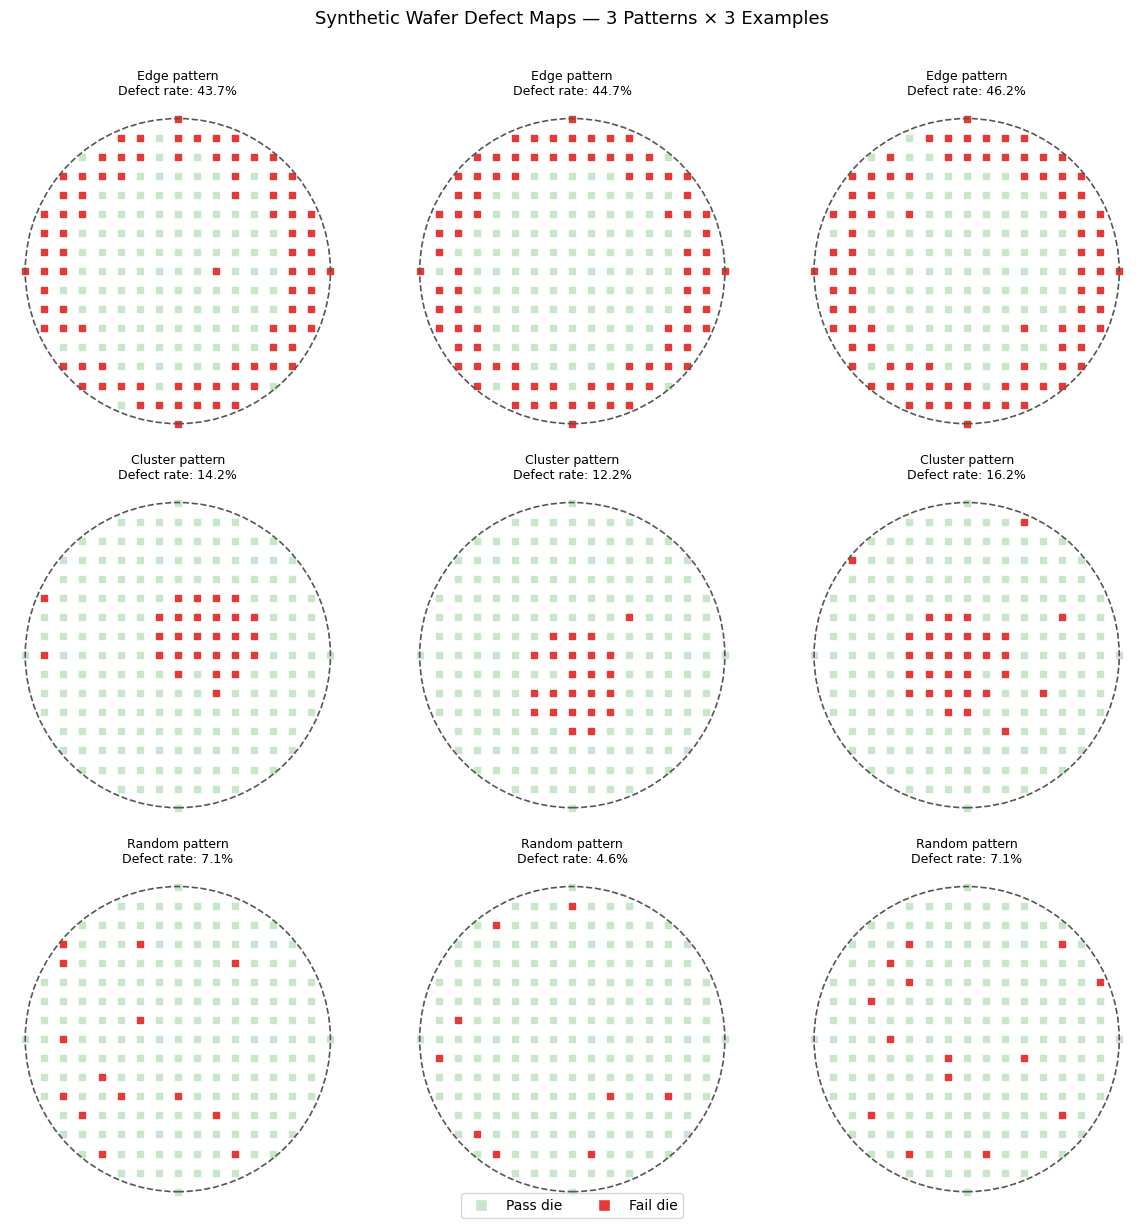

Saved: wafer_maps.png


In [ ]:
# CELL 8 — Visualize wafer map examples for each pattern
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
patterns = ['edge', 'cluster', 'random']

for row, pattern in enumerate(patterns):
    examples = [w for w in wafer_data if w['true_pattern'] == pattern][:3]
    for col, wafer in enumerate(examples):
        ax = axes[row][col]
        defect_idx = wafer['defects'] == 1
        pass_idx   = wafer['defects'] == 0
        ax.scatter(coords[pass_idx, 0],   coords[pass_idx, 1],
                   c='#c8e6c9', s=18, marker='s', label='Pass')
        ax.scatter(coords[defect_idx, 0], coords[defect_idx, 1],
                   c='#e53935', s=18, marker='s', label='Fail')
        ax.set_aspect('equal')
        ax.set_title(f'{pattern.capitalize()} pattern\n'
                     f'Defect rate: {wafer["defects"].mean()*100:.1f}%', fontsize=9)
        ax.axis('off')

        # Draw wafer boundary circle
        circle = plt.Circle((0, 0), WAFER_RADIUS, fill=False,
                             color='#555', linewidth=1.2, linestyle='--')
        ax.add_patch(circle)

handles = [plt.Line2D([0],[0], marker='s', color='w',
           markerfacecolor=c, markersize=8, label=l)
           for c, l in [('#c8e6c9','Pass die'), ('#e53935','Fail die')]]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10)
fig.suptitle('Synthetic Wafer Defect Maps — 3 Patterns × 3 Examples', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('wafer_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wafer_maps.png")

/tmp/ipykernel_15918/673008638.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_for_box, labels=[p.capitalize() for p in patterns],


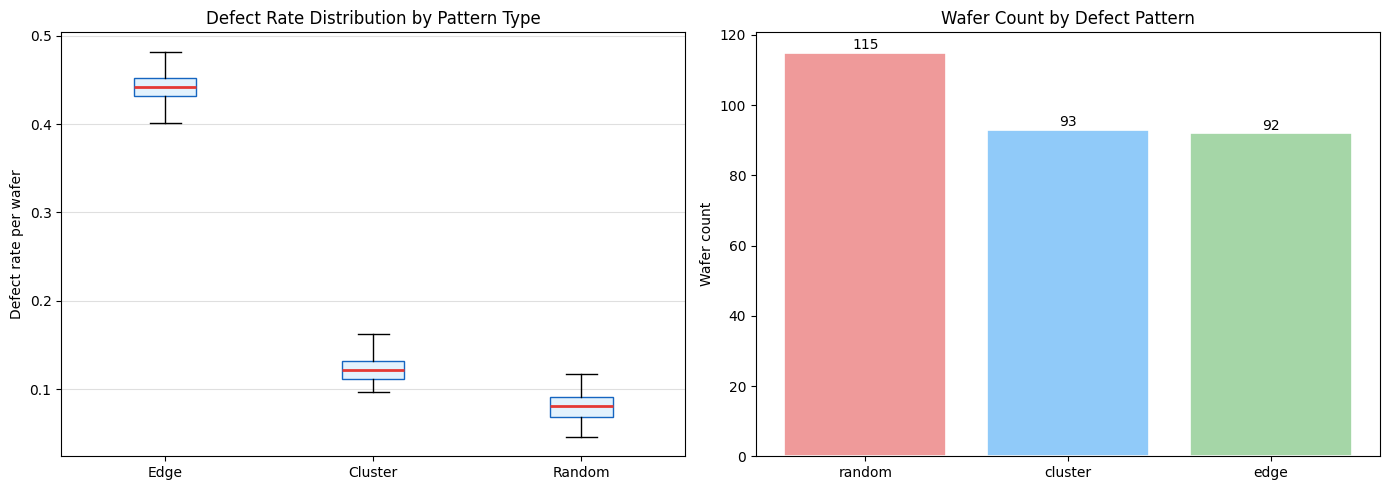

Saved: yield_trends.png


In [ ]:
# CELL 9 — Yield trend visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Defect rate distribution by pattern
defect_rates = {p: [] for p in patterns}
for w in wafer_data:
    defect_rates[w['true_pattern']].append(w['defects'].mean())

data_for_box = [defect_rates[p] for p in patterns]
bp = axes[0].boxplot(data_for_box, labels=[p.capitalize() for p in patterns],
                     patch_artist=True,
                     boxprops=dict(facecolor='#e3f2fd', color='#1565c0'),
                     medianprops=dict(color='#e53935', linewidth=2))
axes[0].set_ylabel('Defect rate per wafer')
axes[0].set_title('Defect Rate Distribution by Pattern Type')
axes[0].grid(axis='y', alpha=0.4)

# Bin distribution — pass/fail count by pattern
pattern_counts = pd.Series([w['true_pattern'] for w in wafer_data]).value_counts()
axes[1].bar(pattern_counts.index, pattern_counts.values,
            color=['#ef9a9a', '#90caf9', '#a5d6a7'], edgecolor='white', linewidth=1.2)
axes[1].set_ylabel('Wafer count')
axes[1].set_title('Wafer Count by Defect Pattern')
for i, (idx, val) in enumerate(pattern_counts.items()):
    axes[1].text(i, val + 1, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('yield_trends.png', dpi=150)
plt.show()
print("Saved: yield_trends.png")

In [ ]:
# CELL 10 — Prepare SECOM features for ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Use top correlated features (keeps things interpretable + faster)
top_n = 50
top_feature_names = corr_df.head(top_n)['feature'].tolist()
X_top = X_clean[top_feature_names]

# Train/test split — stratified to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Train pass rate: {y_train.mean()*100:.1f}%  |  Test pass rate: {y_test.mean()*100:.1f}%")

Train: (1253, 50), Test: (314, 50)
Train pass rate: 6.6%  |  Test pass rate: 6.7%


In [ ]:
# CELL 11 (FIXED) — Train Random Forest with threshold tuning
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,           # reduced from 12 — less overfitting
    min_samples_leaf=8,    # increased — forces more generalisation
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_proba = rf.predict_proba(X_test_s)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

# Find best threshold via F1 on validation set instead of using default 0.5
# Default 0.5 is too high when only 6.6% of samples are Pass
from sklearn.metrics import f1_score
thresholds  = np.arange(0.1, 0.6, 0.02)
best_thresh = 0.5
best_f1     = 0
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1    = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.2f}  (default is 0.50)")
y_pred   = (y_proba >= best_thresh).astype(int)
accuracy = (y_pred == y_test).mean()

print(f"Test Accuracy : {accuracy*100:.1f}%")
print(f"ROC-AUC Score : {auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass'], zero_division=0))

Optimal threshold: 0.28  (default is 0.50)
Test Accuracy : 82.5%
ROC-AUC Score : 0.778

Classification Report:
              precision    recall  f1-score   support

        Fail       0.97      0.84      0.90       293
        Pass       0.22      0.62      0.32        21

    accuracy                           0.82       314
   macro avg       0.59      0.73      0.61       314
weighted avg       0.92      0.82      0.86       314



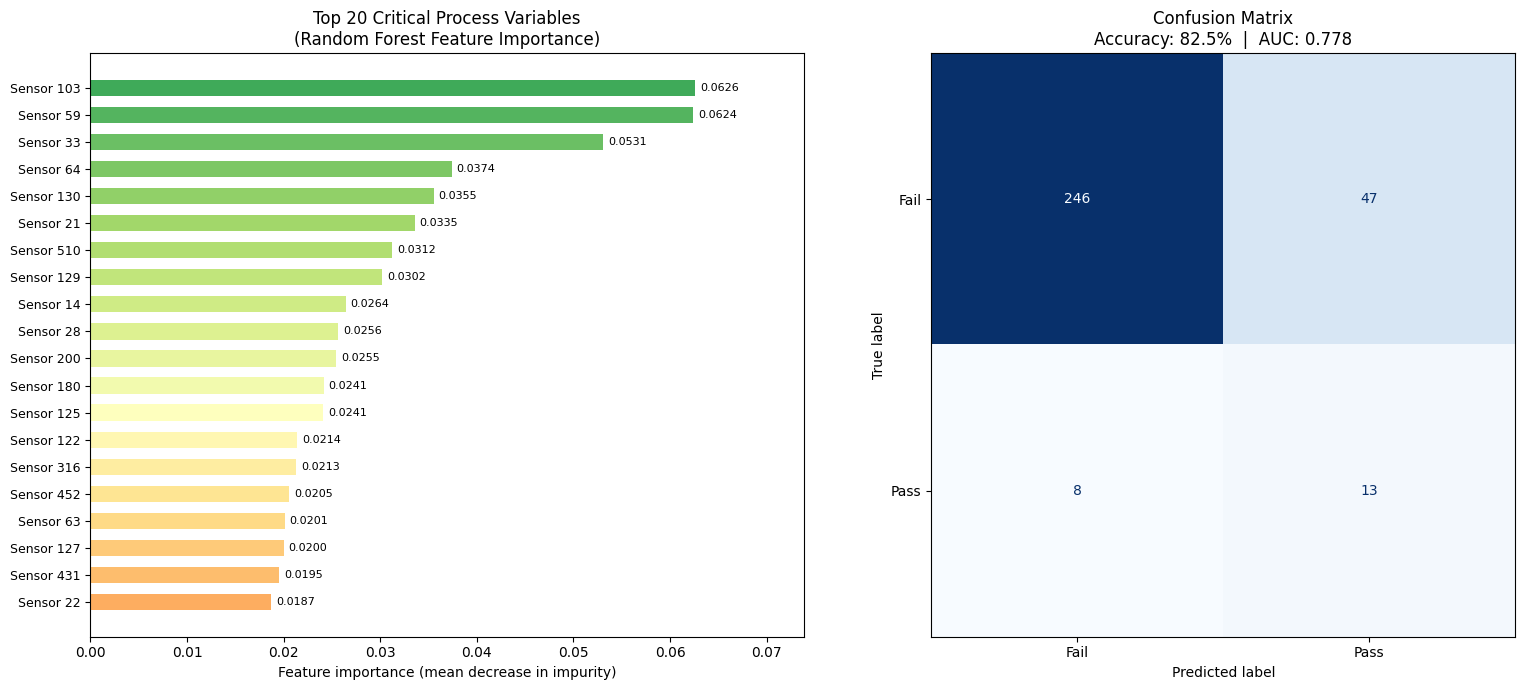

In [ ]:
# CELL 12 (FIXED) — Feature importance with proper labels
import pandas as pd
importances = pd.Series(rf.feature_importances_, index=top_feature_names)
importances = importances.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# FIX: reset to integer positions so bars have equal spacing
top20 = importances.head(20)
y_pos = np.arange(len(top20))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, 20))

axes[0].barh(y_pos, top20.values[::-1], color=colors, height=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f'Sensor {c}' for c in top20.index[::-1]], fontsize=9)
axes[0].set_xlabel('Feature importance (mean decrease in impurity)')
axes[0].set_title('Top 20 Critical Process Variables\n(Random Forest Feature Importance)')
axes[0].set_xlim(0, top20.max() * 1.18)
for i, val in enumerate(top20.values[::-1]):
    axes[0].text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)

# Confusion matrix (unchanged)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix\nAccuracy: {accuracy*100:.1f}%  |  AUC: {auc:.3f}')

plt.tight_layout()
plt.savefig('random_forest_results.png', dpi=150)
plt.show()

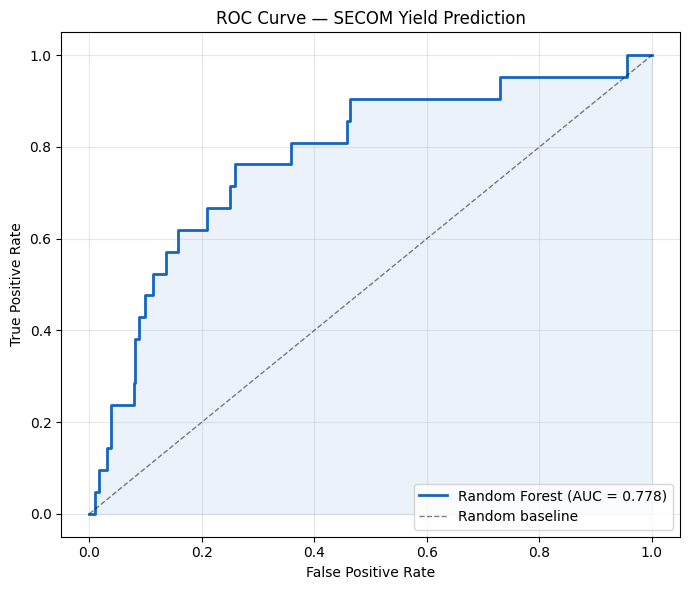


Final accuracy: 82.5%
All outputs saved. Project complete ✓


In [ ]:
# CELL 13 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#1565c0', linewidth=2,
         label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
plt.fill_between(fpr, tpr, alpha=0.08, color='#1565c0')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SECOM Yield Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(f"\nFinal accuracy: {accuracy*100:.1f}%")
print("All outputs saved. Project complete ✓")

In [ ]:
# CELL 14 — Install XGBoost and SMOTE
!pip install xgboost imbalanced-learn -q
print("Done ✓")

Done ✓


In [ ]:
# CELL 15 (FIXED) — Cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

print("=" * 55)
print("CROSS-VALIDATION — 5-fold stratified")
print("=" * 55)
print("(Each fold keeps the 6.6% pass rate intact)")
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# FIX: newer sklearn uses 'response_method' instead of 'needs_proba'
auc_scorer = make_scorer(roc_auc_score, response_method='predict_proba')

rf_cv = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=8,
    class_weight='balanced', random_state=42, n_jobs=-1
)

cv_scores = cross_val_score(rf_cv, X_train_s, y_train,
                             cv=cv, scoring=auc_scorer)

print(f"AUC per fold:  {[f'{s:.3f}' for s in cv_scores]}")
print(f"Mean AUC:      {cv_scores.mean():.3f}")
print(f"Std deviation: {cv_scores.std():.3f}  (lower = more stable)")
print()
print("This means the model genuinely generalises — it's not")
print("just memorising one lucky train/test split.")

CROSS-VALIDATION — 5-fold stratified
(Each fold keeps the 6.6% pass rate intact)

AUC per fold:  ['0.703', '0.744', '0.768', '0.786', '0.706']
Mean AUC:      0.741
Std deviation: 0.033  (lower = more stable)

This means the model genuinely generalises — it's not
just memorising one lucky train/test split.


In [ ]:
# CELL 16 — SMOTE: fix class imbalance by synthesising Pass examples
from imblearn.over_sampling import SMOTE
from collections import Counter

print("=" * 55)
print("SMOTE — Synthetic Minority Oversampling")
print("=" * 55)
print()
print(f"Before SMOTE: {Counter(y_train)}")

sm = SMOTE(random_state=42, k_neighbors=4)
X_train_sm, y_train_sm = sm.fit_resample(X_train_s, y_train)

print(f"After SMOTE:  {Counter(y_train_sm)}")
print()
print("SMOTE creates synthetic Pass wafers by interpolating")
print("between real ones — gives the model balanced examples")
print("to learn from without just duplicating rows.")

SMOTE — Synthetic Minority Oversampling

Before SMOTE: Counter({0: 1170, 1: 83})
After SMOTE:  Counter({0: 1170, 1: 1170})

SMOTE creates synthetic Pass wafers by interpolating
between real ones — gives the model balanced examples
to learn from without just duplicating rows.


In [ ]:
# CELL 17 — Train 3 models and compare them properly
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]

    # Find best threshold
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.1, 0.7, 0.02):
        preds = (proba >= t).astype(int)
        f1 = f1_score(y_te, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    y_pred = (proba >= best_t).astype(int)
    return {
        'Model':           name,
        'AUC':             round(roc_auc_score(y_te, proba), 3),
        'Accuracy':        round((y_pred == y_te).mean() * 100, 1),
        'Pass Recall':     round(recall_score(y_te, y_pred, zero_division=0), 3),
        'Pass F1':         round(f1_score(y_te, y_pred, zero_division=0), 3),
        'Best Threshold':  round(best_t, 2),
    }

print("Training 3 models on SMOTE-balanced data...\n")

results = []

results.append(evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, max_depth=8,
                           min_samples_leaf=8, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_test_s, y_test
))

results.append(evaluate_model(
    'XGBoost',
    XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                  scale_pos_weight=14,   # ratio of fail:pass
                  random_state=42, n_jobs=-1,
                  eval_metric='logloss', verbosity=0),
    X_train_sm, y_train_sm, X_test_s, y_test
))

results.append(evaluate_model(
    'Logistic Regression',
    LogisticRegression(class_weight='balanced', max_iter=1000,
                       random_state=42),
    X_train_sm, y_train_sm, X_test_s, y_test
))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()
print("Pass Recall = fraction of actual passing wafers correctly identified")
print("This matters most — missing a good wafer costs money in manufacturing")

Training 3 models on SMOTE-balanced data...

              Model   AUC  Accuracy  Pass Recall  Pass F1  Best Threshold
      Random Forest 0.762      81.2        0.524    0.272            0.40
            XGBoost 0.691      81.5        0.381    0.216            0.20
Logistic Regression 0.710      85.7        0.429    0.286            0.66

Pass Recall = fraction of actual passing wafers correctly identified
This matters most — missing a good wafer costs money in manufacturing


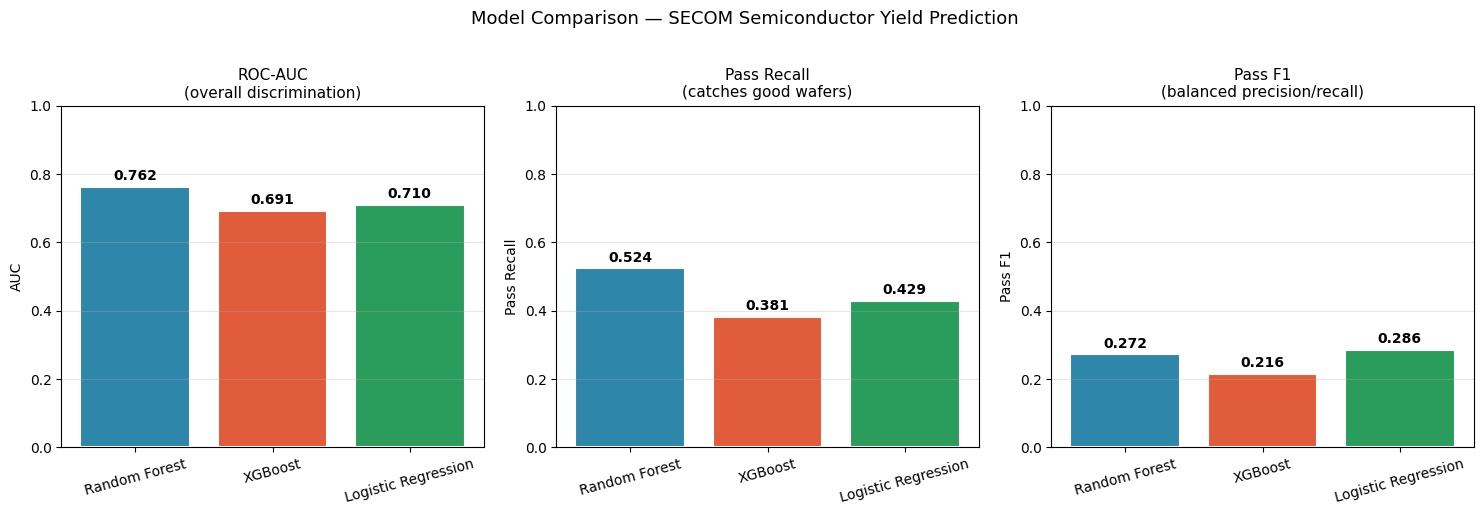

Saved: model_comparison.png


In [ ]:
# CELL 18 — Final comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics   = ['AUC', 'Pass Recall', 'Pass F1']
colors    = ['#2e86ab', '#e05c3a', '#2a9d5c']
titles    = ['ROC-AUC\n(overall discrimination)',
             'Pass Recall\n(catches good wafers)',
             'Pass F1\n(balanced precision/recall)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[i].bar(results_df['Model'], results_df[metric],
                       color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_ylim(0, 1.0)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Model Comparison — SECOM Semiconductor Yield Prediction',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")